In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [7]:
clean_df = pd.read_csv("../data/processed/cleaned_online_retail_all_sales.csv")
customer_df = pd.read_csv("../data/processed/cleaned_online_retail_customer_sales.csv")

clean_df["invoice_date"] = pd.to_datetime(clean_df["invoice_date"])
clean_df["date"] = pd.to_datetime(clean_df["date"])

customer_df["invoice_date"] = pd.to_datetime(customer_df["invoice_date"])
customer_df["date"] = pd.to_datetime(customer_df["date"])

print("Clean data:", clean_df.shape)
print("Customer data:", customer_df.shape)

clean_df.head()

Clean data: (524878, 18)
Customer data: (392692, 18)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,customer_id_missing,is_cancelled,total_amount,date,year,month,day,day_of_week,hour,year_month
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,0,15.30,2010-12-01,2010,12,1,Wednesday,8,2010-12
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,20.34,2010-12-01,2010,12,1,Wednesday,8,2010-12
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,0,22.00,2010-12-01,2010,12,1,Wednesday,8,2010-12
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,20.34,2010-12-01,2010,12,1,Wednesday,8,2010-12
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,20.34,2010-12-01,2010,12,1,Wednesday,8,2010-12


In [8]:
print(clean_df.info())

clean_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   invoice_no           524878 non-null  object        
 1   stock_code           524878 non-null  str           
 2   description          524878 non-null  str           
 3   quantity             524878 non-null  int64         
 4   invoice_date         524878 non-null  datetime64[us]
 5   unit_price           524878 non-null  float64       
 6   customer_id          392692 non-null  float64       
 7   country              524878 non-null  str           
 8   customer_id_missing  524878 non-null  int64         
 9   is_cancelled         524878 non-null  int64         
 10  total_amount         524878 non-null  float64       
 11  date                 524878 non-null  datetime64[us]
 12  year                 524878 non-null  int64         
 13  month                5248

,quantity,invoice_date,unit_price,customer_id,customer_id_missing,is_cancelled,total_amount,date,year,month,day,hour
count,524878.000000,524878,524878.000000,392692.000000,524878.000000,524878.0,524878.000000,524878,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,15287.843865,0.251841,0.0,20.275399,2011-07-04 01:55:49.326891,2010.921904,7.552237,15.022472,13.073991
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.000000,0.0,0.001000,2010-12-01 00:00:00,2010.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,0.000000,0.0,3.900000,2011-03-28 00:00:00,2011.000000,5.000000,7.000000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,0.000000,0.0,9.920000,2011-07-20 00:00:00,2011.000000,8.000000,15.000000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,1.000000,0.0,17.700000,2011-10-19 00:00:00,2011.000000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,1.000000,0.0,168469.600000,2011-12-09 00:00:00,2011.000000,12.000000,31.000000,20.000000
std,156.280031,NaN,36.093028,1713.539549,0.434071,0.0,271.693566,NaN,0.268323,3.508164,8.660738,2.442994


In [9]:
missing_values = clean_df.isnull().sum().sort_values(ascending=False)

missing_values

customer_id            132186
invoice_no                  0
stock_code                  0
description                 0
invoice_date                0
quantity                    0
unit_price                  0
country                     0
customer_id_missing         0
is_cancelled                0
total_amount                0
date                        0
year                        0
month                       0
day                         0
day_of_week                 0
hour                        0
year_month                  0
dtype: int64

In [10]:
total_revenue = clean_df["total_amount"].sum()
total_orders = clean_df["invoice_no"].nunique()
total_products = clean_df["stock_code"].nunique()
total_customers = customer_df["customer_id"].nunique()
total_countries = clean_df["country"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)
print("Total Countries:", total_countries)

Total Revenue: 10642110.8
Total Orders: 19962
Total Products: 3922
Total Customers: 4338
Total Countries: 38


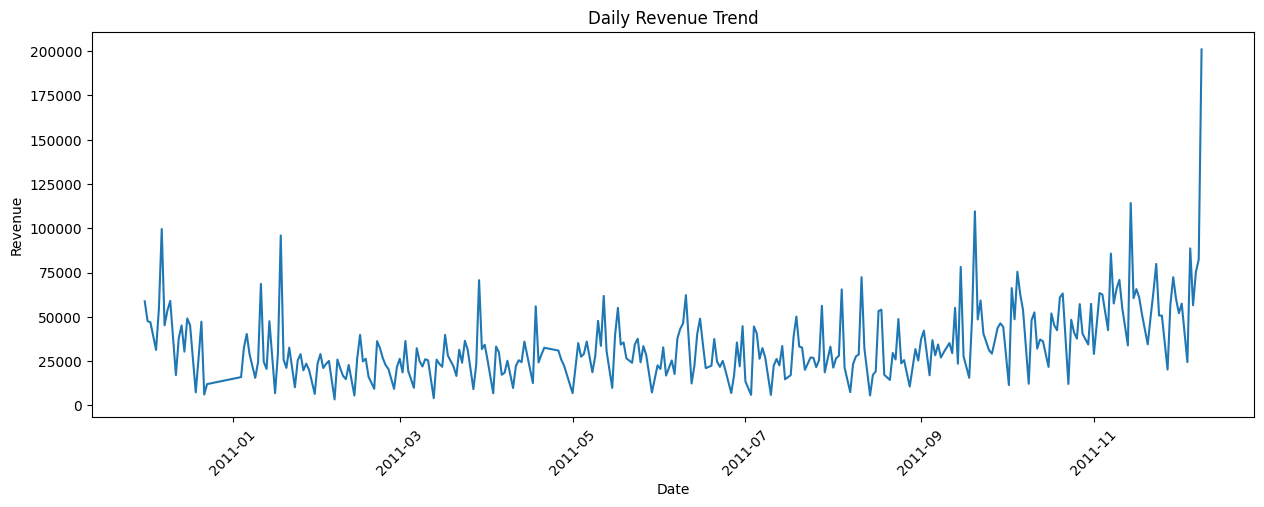

,date,daily_revenue,daily_quantity,daily_orders
0,2010-12-01,58776.79,26818,127
1,2010-12-02,47629.42,31264,142
2,2010-12-03,46898.63,16158,68
3,2010-12-05,31364.63,16242,88
4,2010-12-06,54624.15,21619,102


In [11]:
daily_sales = (
    clean_df.groupby("date")
    .agg(
        daily_revenue=("total_amount", "sum"),
        daily_quantity=("quantity", "sum"),
        daily_orders=("invoice_no", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(15, 5))
plt.plot(daily_sales["date"], daily_sales["daily_revenue"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

daily_sales.head()

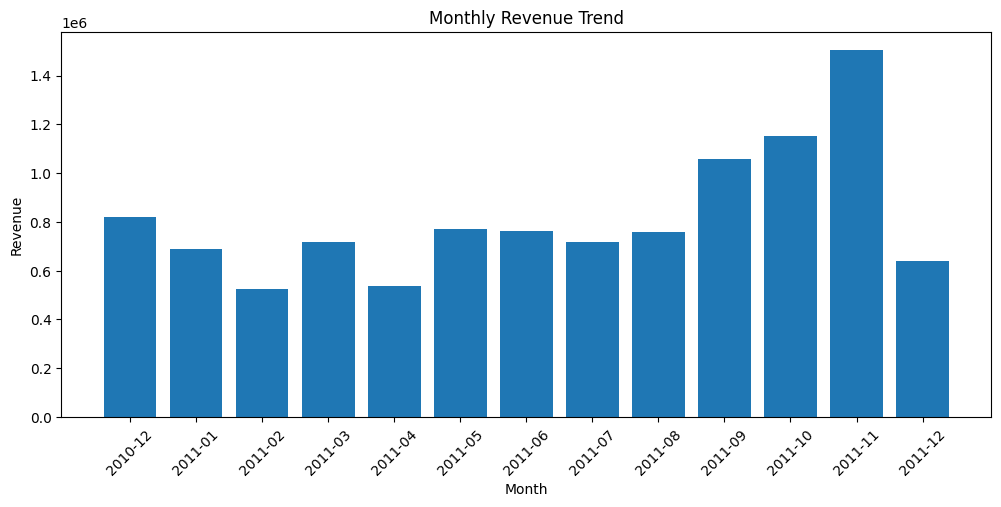

,year_month,monthly_revenue,monthly_quantity,monthly_orders
0,2010-12,821452.730,358019,1559
1,2011-01,689811.610,387099,1086
2,2011-02,522545.560,282934,1100
3,2011-03,716215.260,376599,1454
4,2011-04,536968.491,307953,1246
5,2011-05,769296.610,395001,1681
6,2011-06,760547.010,388511,1533
7,2011-07,718076.121,399693,1476
8,2011-08,757841.380,421020,1362
9,2011-09,1056435.192,569573,1837


In [12]:
monthly_sales = (
    clean_df.groupby("year_month")
    .agg(
        monthly_revenue=("total_amount", "sum"),
        monthly_quantity=("quantity", "sum"),
        monthly_orders=("invoice_no", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.bar(monthly_sales["year_month"], monthly_sales["monthly_revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

monthly_sales

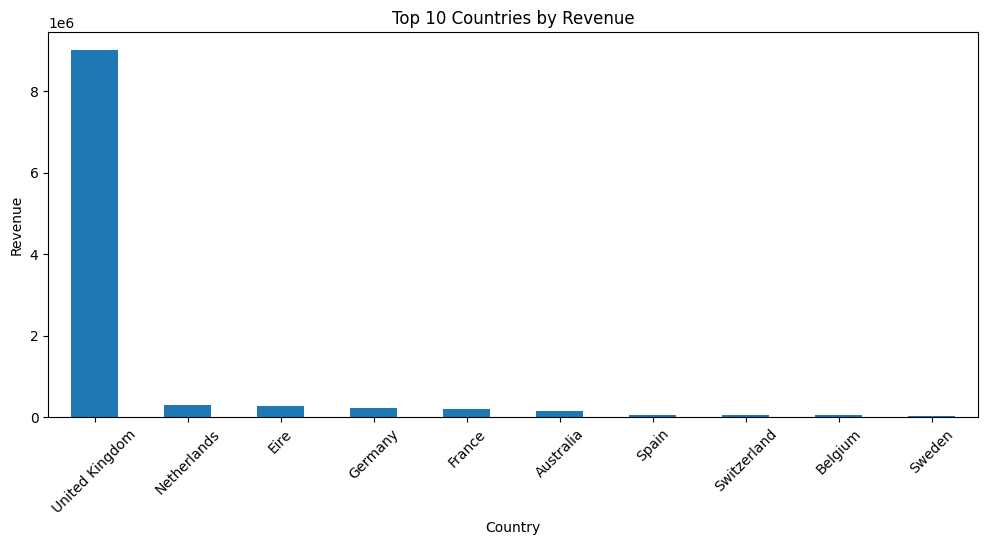

country
United Kingdom    9001744.094
Netherlands        285446.340
Eire               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: total_amount, dtype: float64

In [13]:
country_revenue = (
    clean_df.groupby("country")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
country_revenue.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

country_revenue

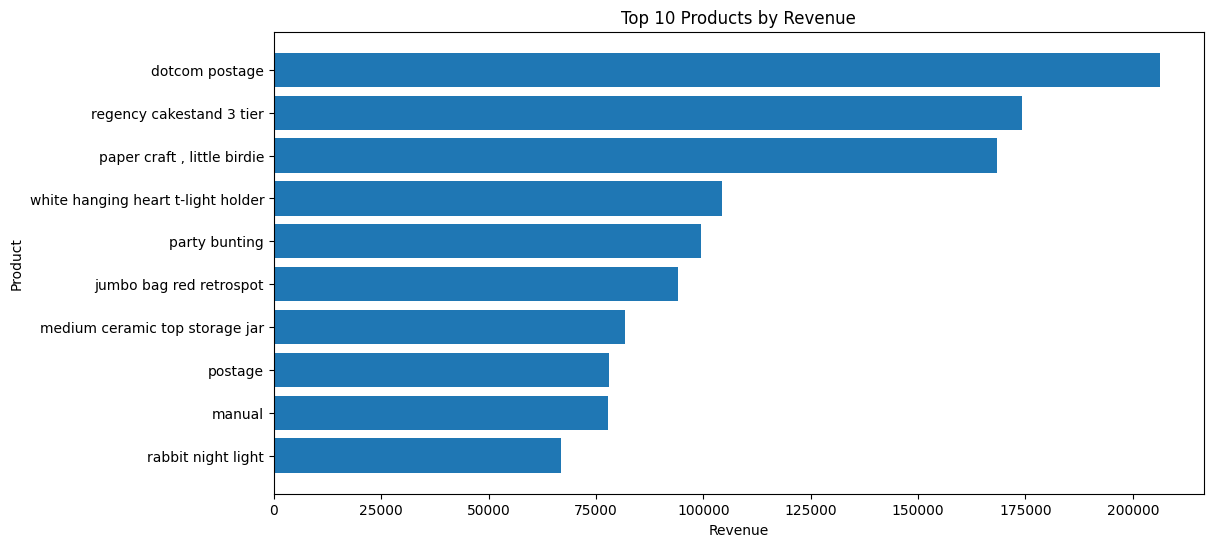

,stock_code,description,total_amount
4147,DOT,dotcom postage,206248.77
1340,22423,regency cakestand 3 tier,174156.54
2665,23843,"paper craft , little birdie",168469.60
3637,85123A,white hanging heart t-light holder,104284.24
2874,47566,party bunting,99445.23
3616,85099B,jumbo bag red retrospot,94159.81
2120,23166,medium ceramic top storage jar,81700.92
4150,POST,postage,78101.88
4148,M,manual,77750.27
2026,23084,rabbit night light,66870.03


In [14]:
top_products_revenue = (
    clean_df.groupby(["stock_code", "description"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values(by="total_amount", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(top_products_revenue["description"], top_products_revenue["total_amount"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

top_products_revenue

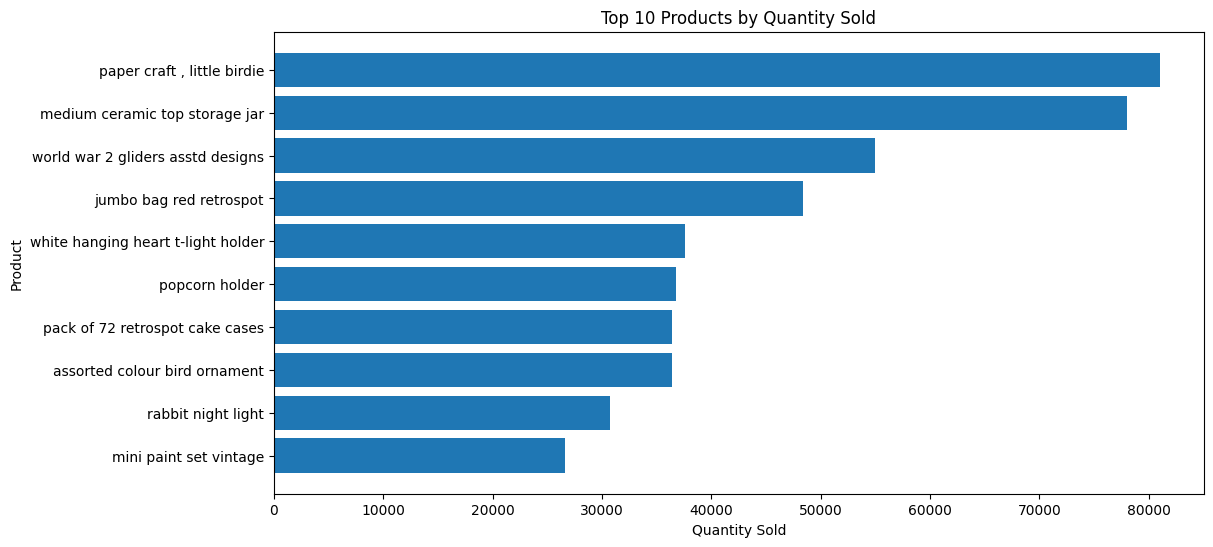

,stock_code,description,quantity
2665,23843,"paper craft , little birdie",80995
2120,23166,medium ceramic top storage jar,78033
3125,84077,world war 2 gliders asstd designs,54951
3616,85099B,jumbo bag red retrospot,48371
3637,85123A,white hanging heart t-light holder,37580
1129,22197,popcorn holder,36749
448,21212,pack of 72 retrospot cake cases,36396
3413,84879,assorted colour bird ornament,36362
2026,23084,rabbit night light,30739
1405,22492,mini paint set vintage,26633


In [15]:
top_products_quantity = (
    clean_df.groupby(["stock_code", "description"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(by="quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(top_products_quantity["description"], top_products_quantity["quantity"])
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

top_products_quantity

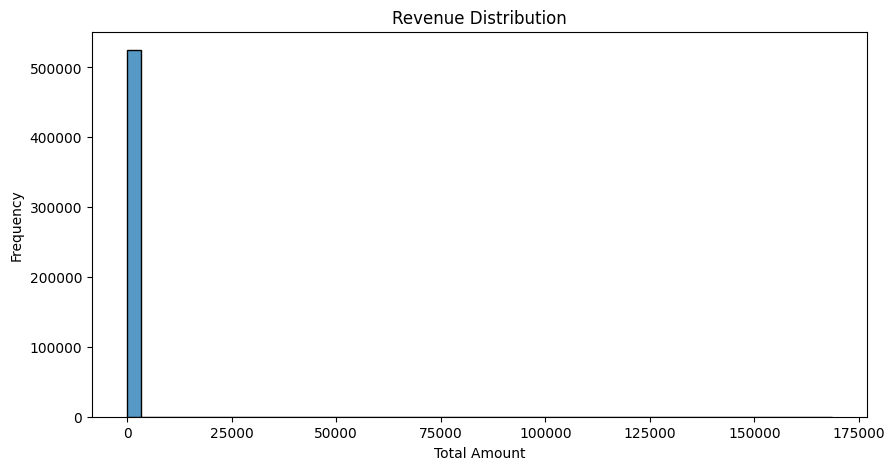

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df["total_amount"], bins=50)
plt.title("Revenue Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

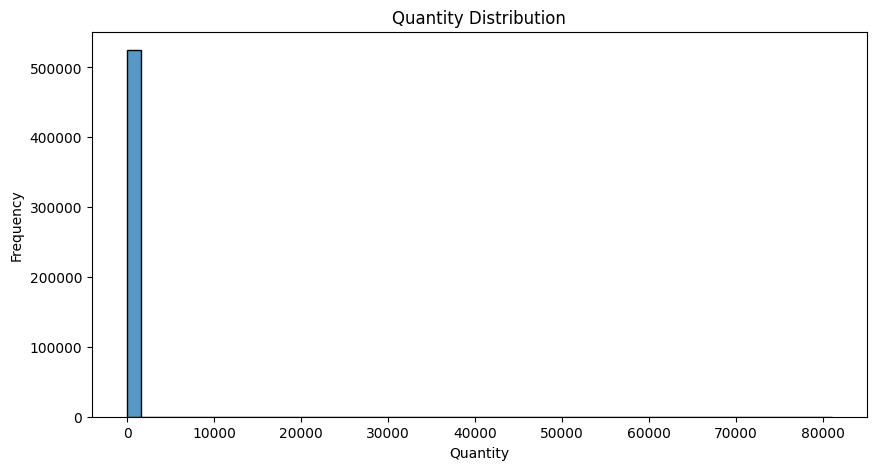

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df["quantity"], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

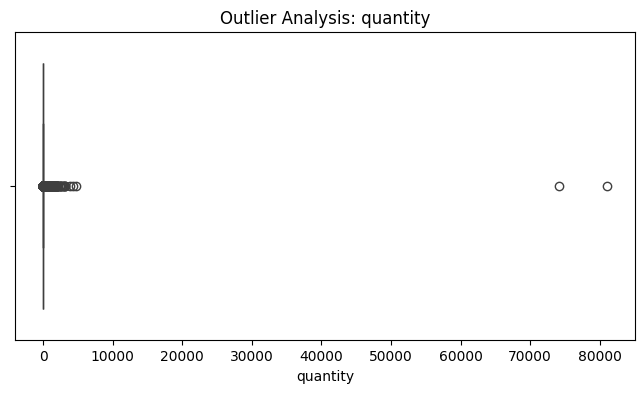

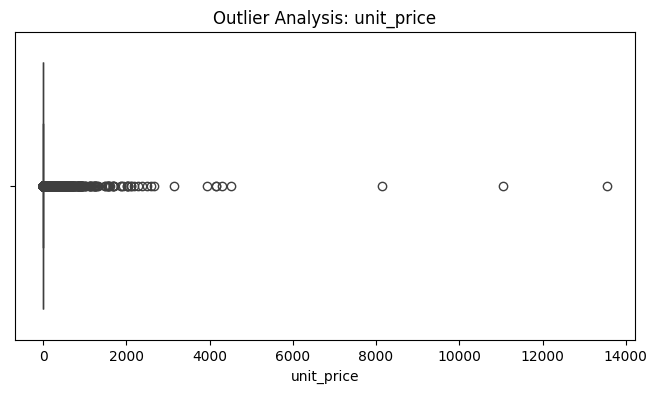

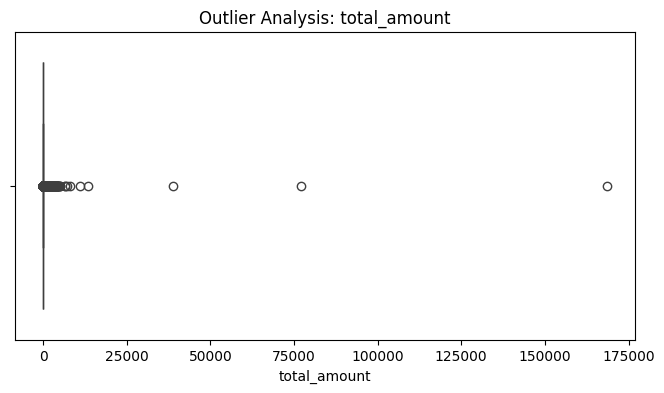

In [18]:
numeric_cols = ["quantity", "unit_price", "total_amount"]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=clean_df[col])
    plt.title(f"Outlier Analysis: {col}")
    plt.show()

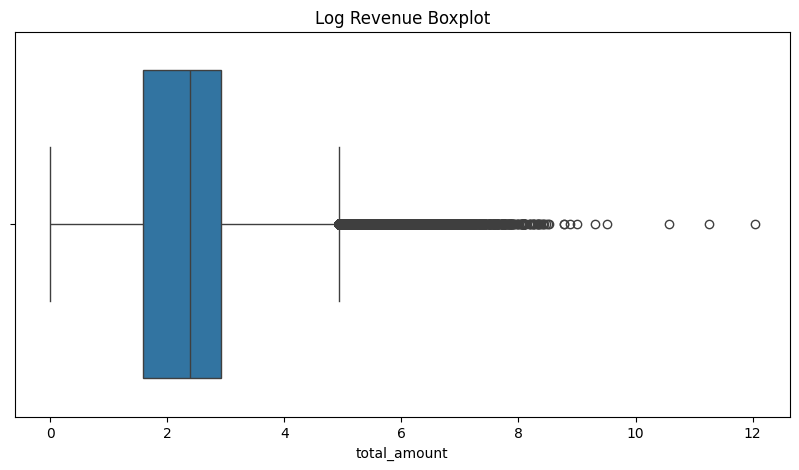

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=np.log1p(clean_df["total_amount"])
)

plt.title("Log Revenue Boxplot")

plt.show()

In [20]:
skewness_summary = clean_df[["quantity", "unit_price", "total_amount"]].skew()

skewness_summary

quantity        469.541785
unit_price      205.085168
total_amount    504.232562
dtype: float64

In [21]:
clean_df["log_quantity"] = np.log1p(clean_df["quantity"])
clean_df["log_unit_price"] = np.log1p(clean_df["unit_price"])
clean_df["log_total_amount"] = np.log1p(clean_df["total_amount"])

clean_df[[
    "quantity", "log_quantity",
    "unit_price", "log_unit_price",
    "total_amount", "log_total_amount"
]].head()

,quantity,log_quantity,unit_price,log_unit_price,total_amount,log_total_amount
0,6,1.945910,2.55,1.266948,15.30,2.791165
1,6,1.945910,3.39,1.479329,20.34,3.060583
2,8,2.197225,2.75,1.321756,22.00,3.135494
3,6,1.945910,3.39,1.479329,20.34,3.060583
4,6,1.945910,3.39,1.479329,20.34,3.060583


In [22]:
quantity_cap = clean_df["quantity"].quantile(0.99)
unit_price_cap = clean_df["unit_price"].quantile(0.99)
amount_cap = clean_df["total_amount"].quantile(0.99)

clean_df["quantity_capped"] = np.where(
    clean_df["quantity"] > quantity_cap,
    quantity_cap,
    clean_df["quantity"]
)

clean_df["unit_price_capped"] = np.where(
    clean_df["unit_price"] > unit_price_cap,
    unit_price_cap,
    clean_df["unit_price"]
)

clean_df["total_amount_capped"] = np.where(
    clean_df["total_amount"] > amount_cap,
    amount_cap,
    clean_df["total_amount"]
)

print("Quantity cap:", quantity_cap)
print("Unit Price cap:", unit_price_cap)
print("Total Amount cap:", amount_cap)

Quantity cap: 100.0
Unit Price cap: 16.98
Total Amount cap: 183.6


In [23]:
clean_df[[
    "quantity",
    "quantity_capped",
    "unit_price",
    "unit_price_capped",
    "total_amount",
    "total_amount_capped"
]].describe()

,quantity,quantity_capped,unit_price,unit_price_capped,total_amount,total_amount_capped
count,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,8.839208,3.922573,3.238820,20.275399,16.971532
std,156.280031,15.321080,36.093028,3.232394,271.693566,27.099001
min,1.000000,1.000000,0.001000,0.001000,0.001000,0.001000
25%,1.000000,1.000000,1.250000,1.250000,3.900000,3.900000
50%,4.000000,4.000000,2.080000,2.080000,9.920000,9.920000
75%,11.000000,11.000000,4.130000,4.130000,17.700000,17.700000
max,80995.000000,100.000000,13541.330000,16.980000,168469.600000,183.600000


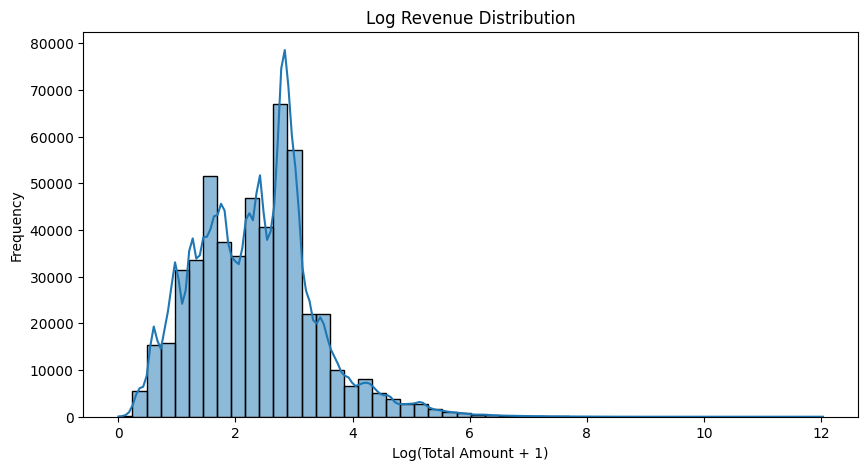

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(clean_df["log_total_amount"], bins=50, kde=True)

plt.title("Log Revenue Distribution")
plt.xlabel("Log(Total Amount + 1)")
plt.ylabel("Frequency")

plt.show()

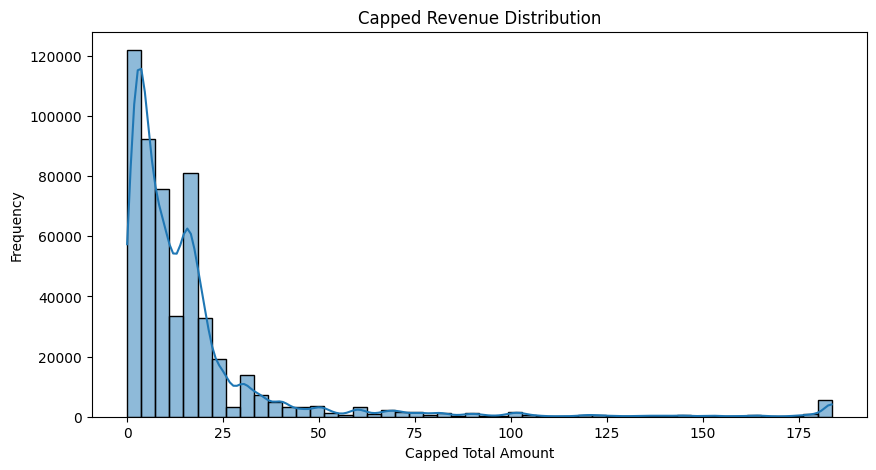

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(clean_df["total_amount_capped"], bins=50, kde=True)

plt.title("Capped Revenue Distribution")
plt.xlabel("Capped Total Amount")
plt.ylabel("Frequency")

plt.show()

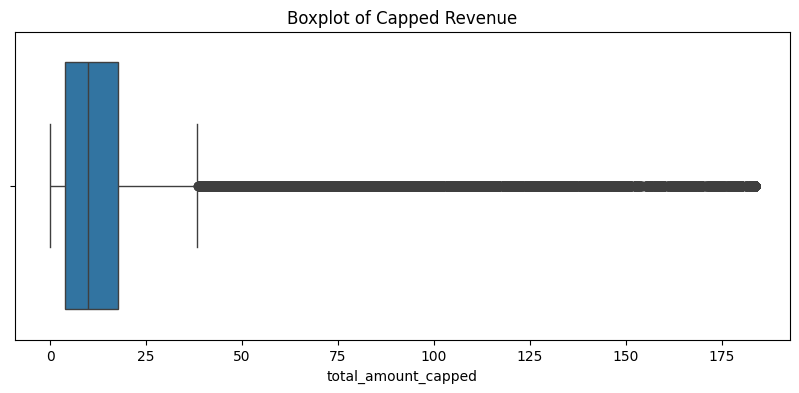

In [26]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=clean_df["total_amount_capped"])

plt.title("Boxplot of Capped Revenue")

plt.show()

In [27]:
clean_df.to_csv("../data/processed/cleaned_online_retail_with_skew_features.csv", index=False)

print("Skewness-handled dataset saved.")

Skewness-handled dataset saved.


In [28]:
skewness_after = clean_df[
    [
        "quantity",
        "log_quantity",
        "quantity_capped",
        "unit_price",
        "log_unit_price",
        "unit_price_capped",
        "total_amount",
        "log_total_amount",
        "total_amount_capped"
    ]
].skew()

skewness_after

quantity               469.541785
log_quantity             1.018872
quantity_capped          4.073532
unit_price             205.085168
log_unit_price           1.111477
unit_price_capped        2.165103
total_amount           504.232562
log_total_amount         0.561024
total_amount_capped      4.195992
dtype: float64

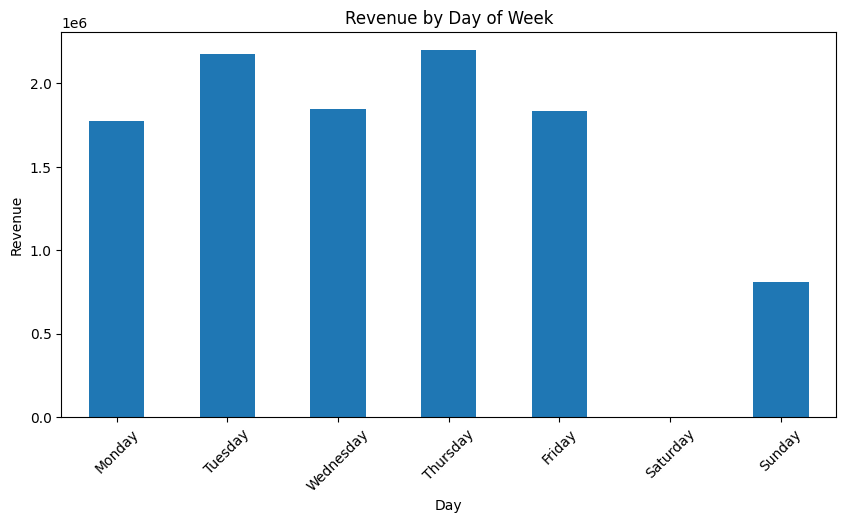

day_of_week
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: total_amount, dtype: float64

In [29]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

sales_by_day = (
    clean_df.groupby("day_of_week")["total_amount"]
    .sum()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
sales_by_day.plot(kind="bar")
plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

sales_by_day

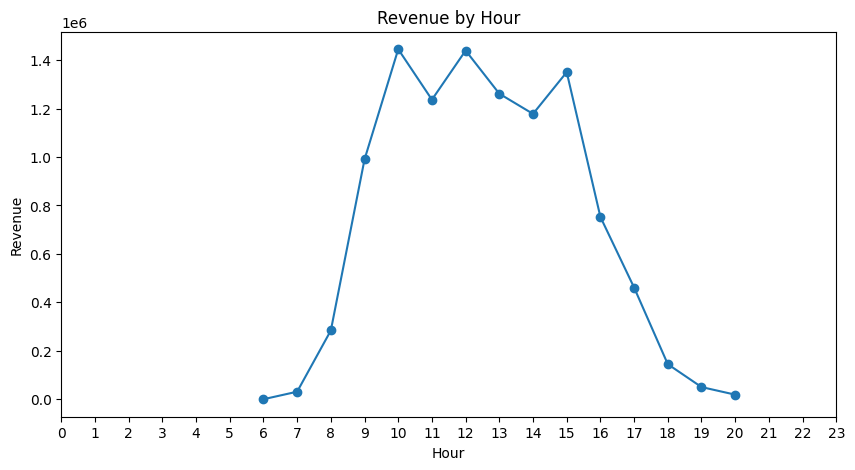

hour
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1177907.521
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: total_amount, dtype: float64

In [30]:
sales_by_hour = clean_df.groupby("hour")["total_amount"].sum()

plt.figure(figsize=(10, 5))
sales_by_hour.plot(kind="line", marker="o")
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.show()

sales_by_hour

In [31]:
customer_behavior = (
    customer_df.groupby("customer_id")
    .agg(
        total_orders=("invoice_no", "nunique"),
        total_spent=("total_amount", "sum"),
        total_quantity=("quantity", "sum"),
        avg_order_value=("total_amount", "mean"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max")
    )
    .reset_index()
)

customer_behavior["customer_lifetime_days"] = (
    customer_behavior["last_purchase"] - customer_behavior["first_purchase"]
).dt.days

customer_behavior.head()

,customer_id,total_orders,total_spent,total_quantity,avg_order_value,first_purchase,last_purchase,customer_lifetime_days
0,12346,1,77183.60,74215,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0
1,12347,7,4310.00,2458,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,365
2,12348,4,1797.24,2341,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,282
3,12349,1,1757.55,631,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,0
4,12350,1,334.40,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0


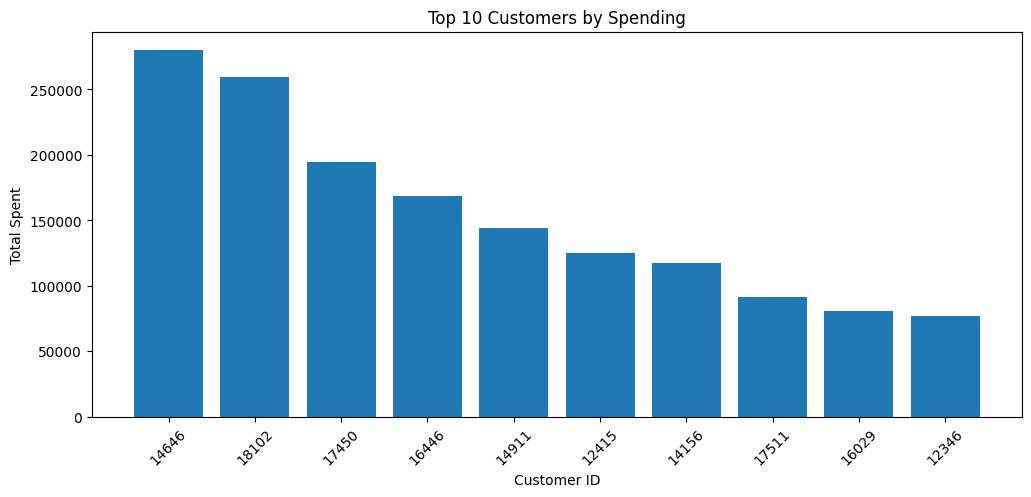

,customer_id,total_orders,total_spent,total_quantity,avg_order_value,first_purchase,last_purchase,customer_lifetime_days
1689,14646,73,280206.02,196915,134.973998,2010-12-20 10:09:00,2011-12-08 12:12:00,353
4201,18102,60,259657.30,64124,602.453132,2010-12-07 16:42:00,2011-12-09 11:50:00,366
3728,17450,46,194390.79,69973,578.544018,2010-12-07 09:23:00,2011-12-01 13:29:00,359
3008,16446,2,168472.50,80997,56157.500000,2011-05-18 09:52:00,2011-12-09 09:15:00,204
1879,14911,201,143711.17,80240,25.345885,2010-12-01 14:05:00,2011-12-08 15:54:00,372
55,12415,21,124914.53,77374,174.950322,2011-01-06 11:12:00,2011-11-15 14:22:00,313
1333,14156,55,117210.08,57768,84.021563,2010-12-03 11:48:00,2011-11-30 10:54:00,361
3771,17511,31,91062.38,64549,94.561142,2010-12-01 10:19:00,2011-12-07 10:12:00,370
2702,16029,63,80850.84,40108,335.480664,2010-12-01 09:57:00,2011-11-01 10:27:00,335
0,12346,1,77183.60,74215,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0


In [32]:
top_customers = customer_behavior.sort_values(
    by="total_spent",
    ascending=False
).head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_customers["customer_id"].astype(str), top_customers["total_spent"])
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.show()

top_customers

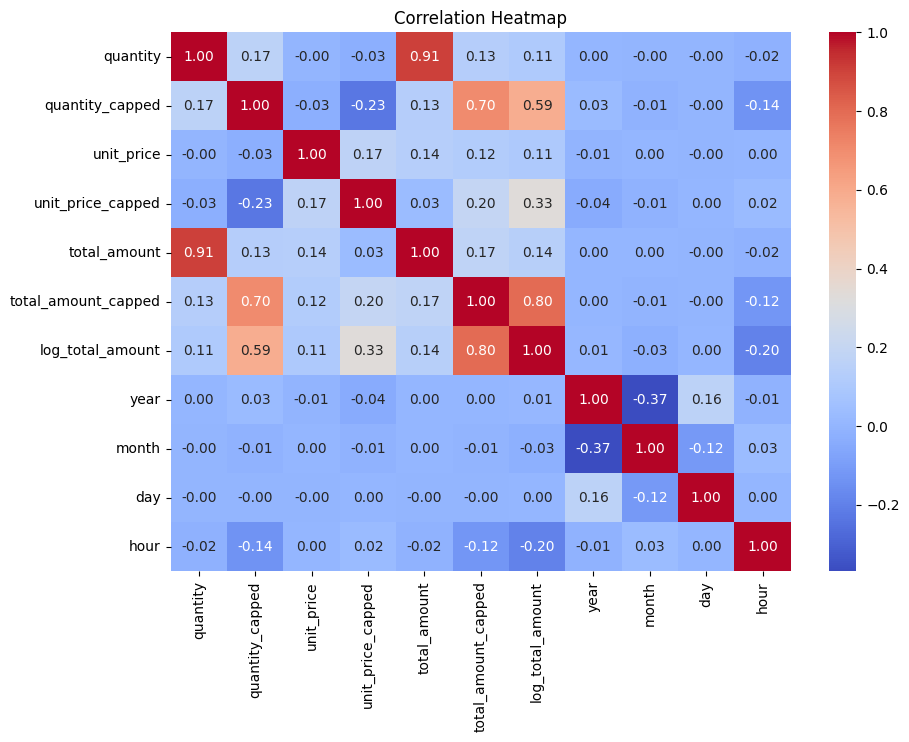

In [33]:
corr_cols = [
    "quantity",
    "quantity_capped",
    "unit_price",
    "unit_price_capped",
    "total_amount",
    "total_amount_capped",
    "log_total_amount",
    "year",
    "month",
    "day",
    "hour"
]

corr_matrix = clean_df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

GREAT EXPECTATIONS BRANCH

In [34]:
import great_expectations as gx
import great_expectations.expectations as gxe

print("Great Expectations imported successfully.")

Great Expectations imported successfully.


In [35]:
context = gx.get_context()

data_source = context.data_sources.add_pandas(
    name="retail_pandas_datasource"
)

data_asset = data_source.add_dataframe_asset(
    name="clean_online_retail_asset"
)

batch_definition = data_asset.add_batch_definition_whole_dataframe(
    name="clean_online_retail_batch"
)

print("GX context, datasource, asset, and batch definition created.")

GX context, datasource, asset, and batch definition created.


In [36]:
suite = gx.ExpectationSuite(
    name="online_retail_cleaning_validation_suite"
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="invoice_no")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="stock_code")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="description")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="invoice_date")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="quantity")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="unit_price")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToBeBetween(
        column="quantity",
        min_value=1
    )
)

suite.add_expectation(
    gxe.ExpectColumnValuesToBeBetween(
        column="unit_price",
        min_value=0.0001
    )
)

suite.add_expectation(
    gxe.ExpectColumnValuesToBeBetween(
        column="total_amount",
        min_value=0.0001
    )
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="date")
)

suite.add_expectation(
    gxe.ExpectColumnValuesToNotBeNull(column="country")
)

suite.add_expectation(
    gxe.ExpectTableRowCountToBeBetween(
        min_value=500000,
        max_value=550000
    )
)

context.suites.add_or_update(suite)

print("Expectation suite created successfully.")

Expectation suite created successfully.


In [37]:
validation_definition = gx.ValidationDefinition(
    name="online_retail_cleaning_validation",
    data=batch_definition,
    suite=suite
)

context.validation_definitions.add_or_update(
    validation_definition
)

validation_results = validation_definition.run(
    batch_parameters={
        "dataframe": clean_df
    }
)

print("Validation success:", validation_results.success)

Calculating Metrics: 100%|██████████| 61/61 [00:00<00:00, 262.63it/s]

Validation success: True


In [38]:
validation_summary = []

for result in validation_results.results:
    validation_summary.append({
        "expectation": result.expectation_config.type,
        "column": result.expectation_config.kwargs.get("column", "table"),
        "success": result.success
    })

validation_summary_df = pd.DataFrame(validation_summary)

validation_summary_df

,expectation,column,success
0,expect_column_values_to_not_be_null,invoice_no,True
1,expect_column_values_to_not_be_null,stock_code,True
2,expect_column_values_to_not_be_null,description,True
3,expect_column_values_to_not_be_null,invoice_date,True
4,expect_column_values_to_not_be_null,quantity,True
5,expect_column_values_to_be_between,quantity,True
6,expect_column_values_to_not_be_null,unit_price,True
7,expect_column_values_to_be_between,unit_price,True
8,expect_column_values_to_be_between,total_amount,True
9,expect_column_values_to_not_be_null,date,True


In [40]:
validation_summary_df.to_csv(
    "../data/processed/great_expectations_validation_summary.csv",
    index=False
)

print("Great Expectations validation summary saved.")

Great Expectations validation summary saved.


In [37]:
clean_df.to_csv(
    "../data/processed/cleaned_online_retail_with_skew_features.csv",
    index=False
)

customer_df.to_csv(
    "../data/processed/customer_sales_for_feature_engineering.csv",
    index=False
)

print("Updated EDA datasets saved successfully.")

Updated EDA datasets saved successfully.


In [38]:
daily_sales.to_csv("../data/processed/eda_daily_sales.csv", index=False)
monthly_sales.to_csv("../data/processed/eda_monthly_sales.csv", index=False)
customer_behavior.to_csv("../data/processed/eda_customer_behavior.csv", index=False)
top_products_revenue.to_csv("../data/processed/eda_top_products_revenue.csv", index=False)
top_products_quantity.to_csv("../data/processed/eda_top_products_quantity.csv", index=False)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


In [39]:
print("EDA Completed Successfully!")

print("\nKey Insights:")
print("1. Revenue distribution is highly right-skewed due to bulk purchases.")
print("2. Log transformation and 99th percentile capping were added.")
print("3. Most revenue comes from a small number of high-value transactions/customers.")
print("4. CustomerID is missing in sales data, but customer-specific dataset is available separately.")
print("5. Date range is from", clean_df["invoice_date"].min(), "to", clean_df["invoice_date"].max())

EDA Completed Successfully!

Key Insights:
1. Revenue distribution is highly right-skewed due to bulk purchases.
2. Log transformation and 99th percentile capping were added.
3. Most revenue comes from a small number of high-value transactions/customers.
4. CustomerID is missing in sales data, but customer-specific dataset is available separately.
5. Date range is from 2010-12-01 08:26:00 to 2011-12-09 12:50:00
